# Cybersecurity — Malicious URL Detection: EDA & Preprocessing

Multi-class classification (benign / defacement / phishing / malware) from a **raw URL string**.
Same lifecycle as the healthcare notebook, with **one deliberate re-ordering**: the raw data is only
`url` + `type` — there are **no numeric or categorical columns to visualize yet** — so **feature
engineering comes *before* visualization** here. Scope: ends at the 80/10/10 split (no modeling).


In [1]:
import warnings; warnings.filterwarnings('ignore')
import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
from urllib.parse import urlparse
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer

sns.set_theme(style='whitegrid')
PAL = ['#2a78d6', '#1baf7a', '#eda100', '#e34948']   # validated CVD-safe: benign, defacement, malware, phishing
CLASSES = ['benign', 'defacement', 'malware', 'phishing']
DATA_PATH = '../../data/cybersecurity-malicious-urls/malicious_phish.csv'
RANDOM_STATE, TARGET = 42, 'type'

## 1. Peek: sample 200 rows, then a different 20 rows

In [2]:
df_full = pd.read_csv(DATA_PATH)
print('shape:', df_full.shape, '| columns:', list(df_full.columns))
df_full.sample(200, random_state=1).head()

shape: (651191, 2) | columns: ['url', 'type']


,url,type
167113,apolloduck.co.za/,benign
387680,acronyms.thefreedictionary.com/WDOM,benign
528900,https://nepan.org.np/Alibaba/Alibaba.com/Login...,phishing
251286,soundonsound.com/sos/aug06/articles/rogernicho...,benign
433650,ottawakiosk.com/hill_cam.html,benign


In [3]:
print('class counts:'); print(df_full[TARGET].value_counts())
print('\nexample URL per class:')
for t in df_full[TARGET].unique():
    print(f'  [{t:11}]', df_full[df_full[TARGET]==t]['url'].iloc[0][:75])

class counts:
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

example URL per class:
  [phishing   ] br-icloud.com.br
  [benign     ] mp3raid.com/music/krizz_kaliko.html
  [defacement ] http://www.garage-pirenne.be/index.php?option=com_content&view=article&id=7
  [malware    ] http://www.824555.com/app/member/SportOption.php?uid=guest&langx=gb


### A different 20 rows

In [4]:
s20 = df_full.sample(20, random_state=99).copy()
s20['url'] = s20['url'].str.slice(0, 70)
s20

,url,type
455172,us-census.org/states/missouri/teams/Jackson-Ka...,benign
272656,lunchboxes.com/,benign
0,br-icloud.com.br,phishing
218140,1albums.com/album.php?artist=Va&album=Ministry...,benign
603408,www.angelfire.com/mo3/ameritractor/,phishing
593425,'web-brasil-seguro-premios.site50.net/comprapr...,benign
343092,http://thenextweb.com/apps/2012/12/21/buysella...,benign
222881,http://www.obvestilo.info/includes/settings/20...,phishing
99131,tviv.org/Alias,benign
503541,careyathletics.com/f/Camps/Bobby_Halford_Summe...,benign


**Observations from the peeks**
- Only **two columns**: `url` (raw string) and `type` (label). No numeric/categorical features exist yet.
- 4 classes, **imbalanced**: benign ≫ defacement ≈ phishing ≫ malware.
- Many URLs **lack a scheme** (`br-icloud.com.br`, `mp3raid.com/...`) — only ~29% start with `http(s)`.
  We must normalize a scheme before parsing host/path.
- Signal must be **engineered** from the string (length, digits, symbols, host, TLD, IP-address host, etc.).

## 2. Data validation & fixes

In [5]:
print('nulls:', df_full.isna().sum().to_dict())
print('duplicate rows:', df_full.duplicated().sum(), '| duplicate urls:', df_full['url'].duplicated().sum())
print('empty/whitespace urls:', (df_full['url'].str.strip() == '').sum())
print('label values:', sorted(df_full[TARGET].unique()))
print('has http(s) scheme: %.1f%%' % (100*df_full['url'].str.lower().str.startswith(('http://','https://')).mean()))
# same url with conflicting labels?
conflict = df_full.groupby('url')[TARGET].nunique()
print('urls with >1 conflicting label:', int((conflict > 1).sum()))

nulls: {'url': 0, 'type': 0}


duplicate rows: 10066 | duplicate urls: 10072
empty/whitespace urls: 0
label values: ['benign', 'defacement', 'malware', 'phishing']


has http(s) scheme: 28.9%


urls with >1 conflicting label: 6


**Validation issues found**
- **10,066 duplicate rows** → drop (would leak identical URLs across train/test).
- A few hundred URLs appear with **conflicting labels** → after dedup, drop URLs that still map to >1 class (ambiguous ground truth).
- No nulls, no empty strings; labels are the clean 4-class set.

In [6]:
df = df_full.drop_duplicates().reset_index(drop=True)
df['url'] = df['url'].str.strip()
# remove URLs with conflicting labels (ambiguous truth)
bad = df.groupby('url')[TARGET].nunique()
df = df[~df['url'].isin(bad[bad > 1].index)].reset_index(drop=True)
print('after dedup + conflict removal:', df.shape)
print(df[TARGET].value_counts(normalize=True).mul(100).round(2).to_dict())

after dedup + conflict removal: (641113, 2)
{'benign': 66.77, 'defacement': 14.87, 'phishing': 14.68, 'malware': 3.69}


## 3. Missing values

In [7]:
print('total missing cells:', int(df.isna().sum().sum()))

total missing cells: 0


No missing values. (Class imbalance is handled at modeling time, out of scope here.)

## 4. Feature engineering (lexical) — **before** visualization
The raw data has nothing numeric to plot, so we derive features first, then visualize them in §5.
All features are row-wise functions of the URL string (leakage-safe).

In [8]:
SHORTENERS = {'bit.ly','tinyurl.com','goo.gl','t.co','ow.ly','is.gd','buff.ly','cutt.ly','rebrand.ly'}
SUSPICIOUS = r'login|secure|account|update|bank|verify|signin|confirm|password|free|webscr|paypal|ebayisapi'

def host_of(u):
    t = u if u.lower().startswith('http') else 'http://' + u
    try:
        return urlparse(t).netloc.split(':')[0]
    except ValueError:                       # malformed (e.g. bad IPv6) -> manual fallback
        return t.split('://', 1)[-1].split('/', 1)[0].split('?', 1)[0].split(':')[0]

def path_of(u):
    t = u if u.lower().startswith('http') else 'http://' + u
    try:
        return urlparse(t).path or ''
    except ValueError:
        rest = t.split('://', 1)[-1]
        return '/' + rest.split('/', 1)[1] if '/' in rest else ''

def entropy(s):
    if not s: return 0.0
    n = len(s); c = Counter(s)
    return float(-sum((v/n) * np.log2(v/n) for v in c.values()))

In [9]:
s = df['url']; low = s.str.lower()
F = pd.DataFrame(index=df.index)
# --- vectorized counts (right-skewed) ---
F['url_len']   = s.str.len()
F['n_dots']    = s.str.count(r'\.')
F['n_hyphen']  = s.str.count('-')
F['n_digits']  = s.str.count(r'\d')
F['n_slash']   = s.str.count('/')
F['n_special'] = s.str.count(r'[@?%=&_~+]')
# --- host / path derived ---
host = s.map(host_of)
F['host_len']     = host.str.len()
F['path_len']     = s.map(path_of).str.len()
F['n_subdomains'] = host.str.count(r'\.')
# --- ratios / entropy ---
F['digit_ratio'] = (F['n_digits'] / F['url_len']).fillna(0)
F['url_entropy'] = s.map(entropy)
# --- binary flags ---
F['has_https']      = low.str.startswith('https').astype(int)
F['has_at']         = s.str.contains('@').astype(int)
F['has_ip']         = host.str.contains(r'^(?:\d{1,3}\.){3}\d{1,3}$', regex=True).astype(int)
F['is_shortened']   = host.str.lower().isin(SHORTENERS).astype(int)
F['has_suspicious'] = low.str.contains(SUSPICIOUS, regex=True).astype(int)
# --- categorical ---
F['scheme'] = np.where(low.str.startswith('https'), 'https',
                       np.where(low.str.startswith('http'), 'http', 'none'))
tld = host.str.rsplit('.', n=1).str[-1].str.lower().where(host.str.contains(r'\.'), 'none')
top_tld = tld.value_counts().head(15).index
F['tld'] = tld.where(tld.isin(top_tld), 'other')
F[TARGET] = df[TARGET].values
print('engineered features:', F.shape[1]-1)
F.head()

engineered features: 18


,url_len,n_dots,n_hyphen,n_digits,n_slash,n_special,host_len,path_len,n_subdomains,digit_ratio,url_entropy,has_https,has_at,has_ip,is_shortened,has_suspicious,scheme,tld,type
0,16,2,1,0,0,0,16,0,2,0.000000,3.375000,0,0,0,0,0,none,br,phishing
1,35,2,0,1,2,1,11,24,1,0.028571,4.079143,0,0,0,0,0,none,com,benign
2,31,2,0,1,3,0,14,17,1,0.032258,3.708093,0,0,0,0,0,none,org,benign
3,88,3,1,7,3,10,21,10,2,0.079545,4.660343,0,0,0,0,0,http,other,defacement
4,235,2,1,22,3,7,23,10,1,0.093617,5.491293,0,0,0,0,0,http,net,defacement


Engineered **16 numeric/flag features** + **2 categoricals** (`tld`, `scheme`):
counts (`url_len`, `n_dots`, `n_digits`, `n_slash`, …), host/path lengths, `digit_ratio`,
character `url_entropy`, and security flags (`has_ip`, `has_at`, `is_shortened`, `has_suspicious`, `has_https`).

## 5. Visualization & pattern finding (on engineered features)

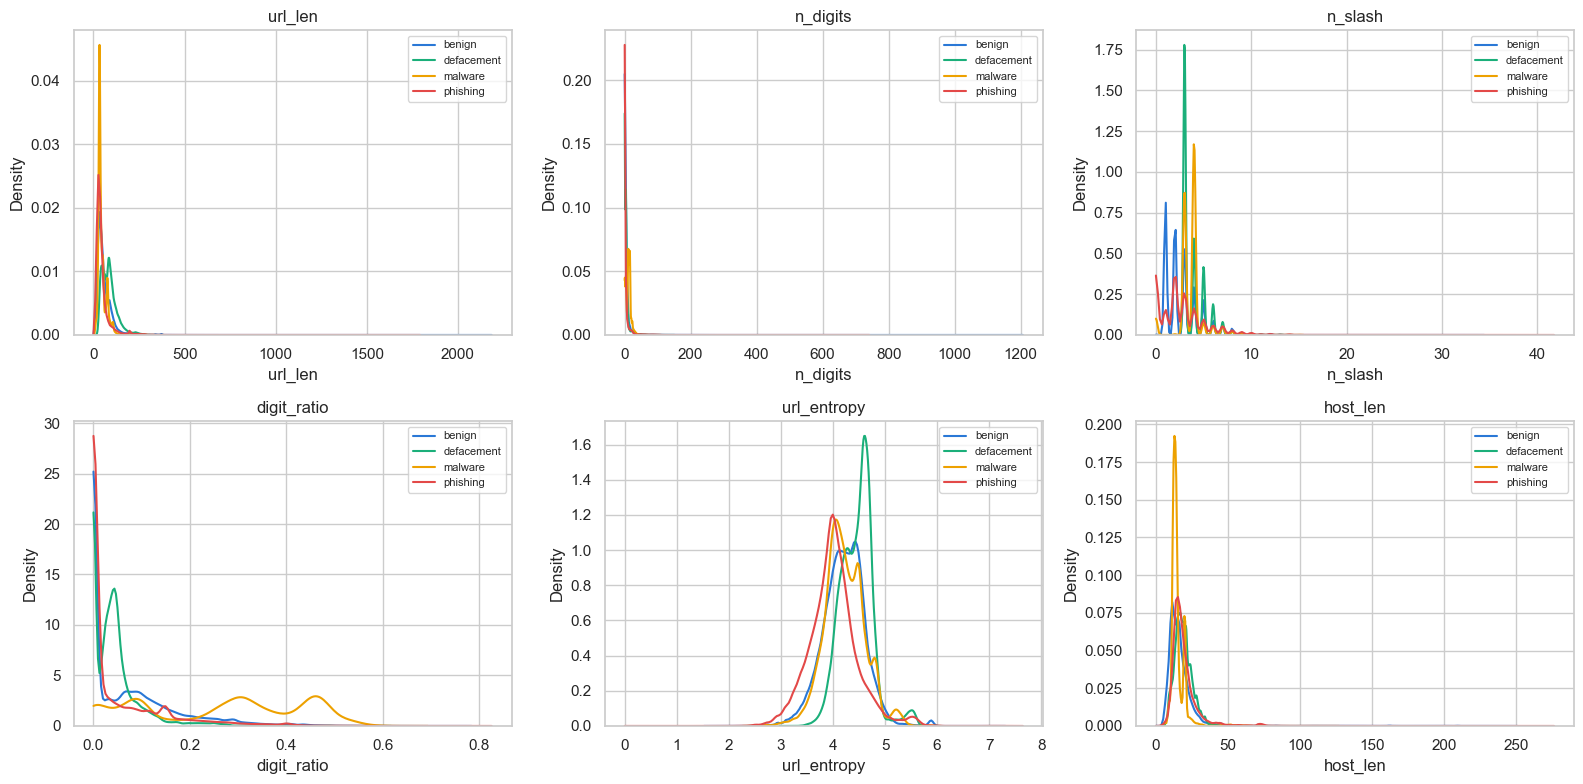

In [10]:
num_show = ['url_len', 'n_digits', 'n_slash', 'digit_ratio', 'url_entropy', 'host_len']
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
for a, c in zip(ax.ravel(), num_show):
    for cls, col in zip(CLASSES, PAL):
        sns.kdeplot(F[F[TARGET]==cls][c], ax=a, color=col, label=cls, common_norm=False, clip=(0, None))
    a.set_title(c); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

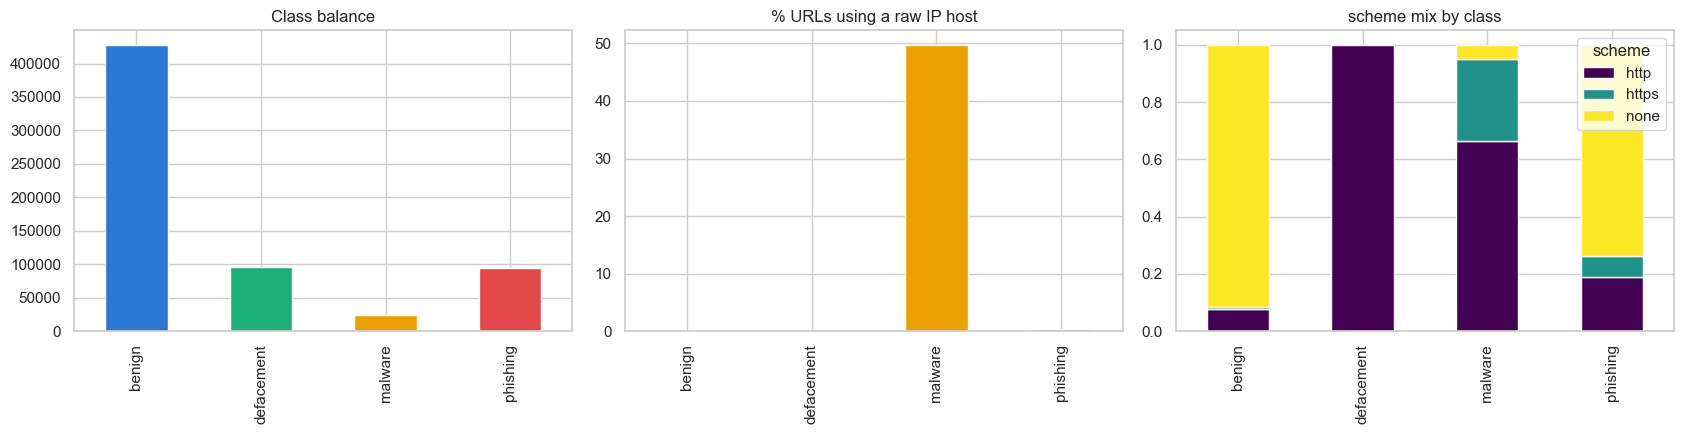

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
df[TARGET].value_counts().loc[CLASSES].plot.bar(ax=ax[0], color=PAL); ax[0].set_title('Class balance'); ax[0].set_xlabel('')
(F.groupby(TARGET)['has_ip'].mean()*100).loc[CLASSES].plot.bar(ax=ax[1], color=PAL); ax[1].set_title('% URLs using a raw IP host'); ax[1].set_xlabel('')
pd.crosstab(F[TARGET], F['scheme'], normalize='index').loc[CLASSES].plot.bar(stacked=True, ax=ax[2], colormap='viridis'); ax[2].set_title('scheme mix by class'); ax[2].set_xlabel('')
plt.tight_layout(); plt.show()

In [12]:
F.groupby(TARGET)[['url_len','n_dots','n_digits','n_slash','digit_ratio','url_entropy','has_ip','has_https','has_suspicious']].mean().loc[CLASSES].round(3)

,url_len,n_dots,n_digits,n_slash,digit_ratio,url_entropy,has_ip,has_https,has_suspicious
type,,,,,,,,,
benign,57.676,1.938,5.608,2.735,0.072,4.210,0.000,0.005,0.081
defacement,86.128,2.840,4.569,3.834,0.044,4.456,0.000,0.000,0.011
malware,46.610,3.058,11.070,3.659,0.260,4.219,0.498,0.284,0.010
phishing,45.854,2.485,3.678,2.661,0.047,4.011,0.003,0.074,0.125


**Patterns found** (from the table + plots)
- **defacement**: longest URLs and most path slashes (deep CMS paths).
- **malware**: highest digit count / `digit_ratio`, and **~50% use a raw IP host** (`has_ip`) plus more `https` — the standout signal.
- **phishing**: short URLs, low entropy, occasional `@`/suspicious keywords.
- **benign**: rarely uses IP hosts or https-in-string; moderate length.
- Every engineered feature shows class separation → the lexical features are informative. `host` (raw string, high-cardinality) is **dropped** — we keep only the derived `tld`.

## 6. Split first (80/10/10, stratified), then fit transforms on train only

In [13]:
X, y = F.drop(columns=[TARGET]), F[TARGET]
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=.20, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test   = train_test_split(X_tmp, y_tmp, test_size=.50, stratify=y_tmp, random_state=RANDOM_STATE)
print('sizes train/val/test:', len(X_train), len(X_val), len(X_test))
print('class mix preserved (train):', y_train.value_counts(normalize=True).round(3).to_dict())

sizes train/val/test: 512890 64111 64112
class mix preserved (train): {'benign': 0.668, 'defacement': 0.149, 'phishing': 0.147, 'malware': 0.037}


## 7. Transformations + scaling (numeric) + one-hot (categorical)
Right-skewed counts get `log1p` before scaling; ratios/entropy scaled directly; flags passed through;
`tld`/`scheme` one-hot encoded. Fit on **train only**.

In [14]:
log_cols  = ['url_len','n_dots','n_hyphen','n_digits','n_slash','n_special','host_len','path_len','n_subdomains']
num_cols  = ['digit_ratio','url_entropy']
bin_cols  = ['has_https','has_at','has_ip','is_shortened','has_suspicious']
cat_cols  = ['tld','scheme']

log_pipe = Pipeline([('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
                     ('scale', StandardScaler())])
pre = ColumnTransformer([
    ('log', log_pipe, log_cols),
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('bin', 'passthrough', bin_cols),
])
X_train_t = pre.fit_transform(X_train)
X_val_t   = pre.transform(X_val)
X_test_t  = pre.transform(X_test)
feat_names = pre.get_feature_names_out()
print('transformed shapes:', X_train_t.shape, X_val_t.shape, X_test_t.shape, '| n_features:', len(feat_names))

transformed shapes: (512890, 35) (64111, 35) (64112, 35) | n_features: 35


In [15]:
print('Any NaN? train/val/test:', np.isnan(X_train_t).any(), np.isnan(X_val_t).any(), np.isnan(X_test_t).any())
pd.DataFrame(X_train_t, columns=feat_names).iloc[:, :6].describe().T.round(3)

Any NaN? train/val/test: False False False


,count,mean,std,min,25%,50%,75%,max
log__url_len,512890.0,0.0,1.0,-4.643,-0.688,-0.070,0.709,6.220
log__n_dots,512890.0,0.0,1.0,-3.047,-1.108,0.026,0.830,7.472
log__n_hyphen,512890.0,0.0,1.0,-0.723,-0.723,-0.723,0.699,5.073
log__n_digits,512890.0,-0.0,1.0,-0.973,-0.973,-0.013,0.727,5.108
log__n_slash,512890.0,0.0,1.0,-2.609,-0.326,0.272,0.735,5.157
log__n_special,512890.0,0.0,1.0,-0.664,-0.664,-0.664,0.587,5.621


## 8. Summary
- Dropped 10,066 duplicates + URLs with conflicting labels; **no missing values**.
- Raw data was only `url` + `type`, so we **engineered 18 lexical features** (counts, host/path, entropy, security flags, `tld`, `scheme`) **before** visualizing.
- Patterns: **malware → IP hosts + digits**, **defacement → long deep paths**, **phishing → short/low-entropy** — all features show class separation.
- Log-transformed skewed counts, scaled numerics, one-hot encoded `tld`/`scheme`, **fit on train only** (leakage-safe).
- Output: `X_{train,val,test}_t` (80/10/10, stratified 4-class) with matching `y_*`, ready for modeling.
- **Next (out of scope):** class-imbalance handling + multi-class model, evaluated with macro-F1 / per-class recall.